In [ ]:
# ============================================================
# Experiment 1: H4 Mediation + H5 Moderation (Colab-ready)
# Data: wide format (1 row per participant)
# Columns:
#   apology_type (healing/defensive/no_apology), scenario (1/2/3)
#   dRes_valence, S_mean
#   action_harmony, action_distance
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

In [13]:
import pandas as pd
# -----------------------------
# 1) Load data
# -----------------------------
path = "experiment1_analysis_numeric.xlsx"  # upload in Colab and keep same name
df = pd.read_excel(path)

# Keep only needed columns (safe)
needed = ["apology_type","scenario","dRes_valence","S_mean","action_harmony","action_distance"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[needed].copy()

In [3]:
# Categorical coding
df["scenario"] = df["scenario"].astype("category")
df["apology_type"] = df["apology_type"].astype("category")

# Set reference category to healing
cats = list(df["apology_type"].cat.categories)
if "healing" not in cats:
    raise ValueError(f"'healing' not found in apology_type categories: {cats}")

new_order = ["healing"] + [c for c in cats if c != "healing"]
df["apology_type"] = df["apology_type"].cat.reorder_categories(new_order, ordered=False)

In [4]:
# Drop rows with missing (just in case)
df = df.dropna()

print("N =", len(df))
print(df.head())

N = 178
  apology_type scenario  dRes_valence    S_mean  action_harmony  \
0      healing        1      3.555556  4.142857            4.50   
1      healing        1      0.000000  7.000000            7.00   
2      healing        1      5.222222  5.857143            3.75   
3      healing        1      5.111111  3.857143            3.25   
4      healing        1      3.888889  5.285714            5.00   

   action_distance  
0             4.00  
1             1.00  
2             3.25  
3             5.25  
4             4.25  


In [5]:
# -----------------------------
# Helper: robust OLS
# -----------------------------
def fit_ols(formula, data, robust="HC3"):
    return smf.ols(formula, data=data).fit(cov_type=robust)

In [6]:
# ============================================================
# H4: Mediation
# IV: apology_type (3 levels, healing as reference)
# M: S_mean
# DV: action_harmony  (and optionally action_distance)
#
# We estimate indirect effects for:
#   defensive vs healing: a_def * b
#   no_apology vs healing: a_no * b
# with bootstrap CI
# ============================================================

print("\n====================")
print("H4: MedIATION (DV = action_harmony)")
print("====================")


H4: MedIATION (DV = action_harmony)


In [33]:
import statsmodels.formula.api as smf
# a-path model: M ~ apology_type + scenario
m_a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", df)
print("\n[a-path] S_mean ~ apology_type + scenario")
print(m_a.summary())


[a-path] S_mean ~ apology_type + scenario
                            OLS Regression Results                            
Dep. Variable:                 S_mean   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     109.8
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.13e-46
Time:                        04:17:03   Log-Likelihood:                -282.80
No. Observations:                 178   AIC:                             575.6
Df Residuals:                     173   BIC:                             591.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [15]:
summary_text = m_a.summary().as_text()
file_name = 'ols_summary_a_path.txt'
with open(file_name, 'w') as f:
    f.write(summary_text)
print(f"OLS summary saved to {file_name}")

OLS summary saved to ols_summary_a_path.txt


In [16]:
summary_text_b = m_b.summary().as_text()
file_name_b = 'ols_summary_b_path.txt'
with open(file_name_b, 'w') as f:
    f.write(summary_text_b)
print(f"OLS summary saved to {file_name_b}")

OLS summary saved to ols_summary_b_path.txt


In [10]:
# b & c' model: DV ~ apology_type + M + scenario
m_b = fit_ols("action_harmony ~ C(apology_type) + S_mean + C(scenario)", df)
print("\n[b, c'] action_harmony ~ apology_type + S_mean + scenario")
print(m_b.summary())


[b, c'] action_harmony ~ apology_type + S_mean + scenario
                            OLS Regression Results                            
Dep. Variable:         action_harmony   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     59.81
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           7.35e-36
Time:                        04:01:23   Log-Likelihood:                -266.77
No. Observations:                 178   AIC:                             545.5
Df Residuals:                     172   BIC:                             564.6
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [43]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [19]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")


Point estimates (indirect effects):
Indirect (defensive vs healing) = a_def * b = nan
Indirect (no_apology vs healing) = a_no  * b = -0.6643


In [34]:
import statsmodels.formula.api as smf
# a-path model: M ~ apology_type + scenario
m_a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", df)
print("\n[a-path] S_mean ~ apology_type + scenario")
print(m_a.summary())


[a-path] S_mean ~ apology_type + scenario
                            OLS Regression Results                            
Dep. Variable:                 S_mean   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     109.8
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.13e-46
Time:                        04:17:03   Log-Likelihood:                -282.80
No. Observations:                 178   AIC:                             575.6
Df Residuals:                     173   BIC:                             591.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [35]:
import statsmodels.formula.api as smf
# a-path model: M ~ apology_type + scenario
m_a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", df)
print("\n[a-path] S_mean ~ apology_type + scenario")
print(m_a.summary())


[a-path] S_mean ~ apology_type + scenario
                            OLS Regression Results                            
Dep. Variable:                 S_mean   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     109.8
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.13e-46
Time:                        04:17:04   Log-Likelihood:                -282.80
No. Observations:                 178   AIC:                             575.6
Df Residuals:                     173   BIC:                             591.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [44]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [37]:
import statsmodels.formula.api as smf
# a-path model: M ~ apology_type + scenario
m_a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", df)
print("\n[a-path] S_mean ~ apology_type + scenario")
print(m_a.summary())


[a-path] S_mean ~ apology_type + scenario
                            OLS Regression Results                            
Dep. Variable:                 S_mean   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     109.8
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.13e-46
Time:                        04:17:05   Log-Likelihood:                -282.80
No. Observations:                 178   AIC:                             575.6
Df Residuals:                     173   BIC:                             591.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [45]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [40]:
summary_text_mod1 = mod1.summary().as_text()
file_name_mod1 = 'ols_summary_mod1.txt'
with open(file_name_mod1, 'w') as f:
    f.write(summary_text_mod1)
print(f"OLS summary saved to {file_name_mod1}")

OLS summary saved to ols_summary_mod1.txt


In [25]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")


Point estimates (indirect effects):
Indirect (defensive vs healing) = a_def * b = nan
Indirect (no_apology vs healing) = a_no  * b = nan


In [39]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")


Bootstrap successful samples: 3000

Bootstrap 95% CI (indirect effects):
Defensive vs Healing: nan, CI (np.float64(-1.8993292330560057), np.float64(-1.095710249187923))
No-apology vs Healing: nan, CI (np.float64(-2.6757205447940313), np.float64(-1.649394246595219))


In [29]:
# Save mediation results
med_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def, ind_no],
    "ci_low": [ci_def[0], ci_no[0]],
    "ci_high": [ci_def[1], ci_no[1]],
    "boot_n": [len(boot), len(boot)]
})
med_out.to_csv("H4_mediation_indirect_action_harmony.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_harmony.csv")


Saved: H4_mediation_indirect_action_harmony.csv


In [46]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")


H4 (optional): Mediation (DV = action_distance)
                            OLS Regression Results                            
Dep. Variable:        action_distance   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     18.84
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           6.51e-15
Time:                        04:21:16   Log-Likelihood:                -291.19
No. Observations:                 178   AIC:                             594.4
Df Residuals:                     172   BIC:                             613.5
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [31]:
# ============================================================
# H5: Moderation (Amplification)
# DV: action_harmony (and action_distance)
# Predictor: dRes_valence
# Moderator: S_mean
# Model: DV ~ dRes_valence * S_mean + apology_type + scenario
# Focus: interaction term dRes_valence:S_mean
# ============================================================

print("\n====================")
print("H5: MODERATION (DV = action_harmony)")
print("====================")


H5: MODERATION (DV = action_harmony)


In [32]:
# Mean-center for cleaner interpretation
df["dRes_c"] = df["dRes_valence"] - df["dRes_valence"].mean()
df["S_c"] = df["S_mean"] - df["S_mean"].mean()

mod1 = fit_ols(
    "action_harmony ~ dRes_c * S_c + C(apology_type) + C(scenario)",
    df
)
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:         action_harmony   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     44.72
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.05e-35
Time:                        04:15:20   Log-Likelihood:                -266.70
No. Observations:                 178   AIC:                             549.4
Df Residuals:                     170   BIC:                             574.8
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [41]:
# DV = action_distance (often opposite direction; still test same interaction)
print("\n====================")
print("H5: MODERATION (DV = action_distance)")
print("====================")

mod2 = fit_ols(
    "action_distance ~ dRes_c * S_c + C(apology_type) + C(scenario)",
    df
)
print(mod2.summary())


H5: MODERATION (DV = action_distance)
                            OLS Regression Results                            
Dep. Variable:        action_distance   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     15.95
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           5.07e-16
Time:                        04:18:23   Log-Likelihood:                -289.87
No. Observations:                 178   AIC:                             595.7
Df Residuals:                     170   BIC:                             621.2
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [42]:
# Save coefficient tables
coef1 = pd.DataFrame({"term": mod1.params.index, "coef": mod1.params.values, "p": mod1.pvalues.values})
coef2 = pd.DataFrame({"term": mod2.params.index, "coef": mod2.params.values, "p": mod2.pvalues.values})
coef1.to_csv("H5_moderation_action_harmony_coefs.csv", index=False)
coef2.to_csv("H5_moderation_action_distance_coefs.csv", index=False)
print("\nSaved: H5_moderation_action_harmony_coefs.csv, H5_moderation_action_distance_coefs.csv")


Saved: H5_moderation_action_harmony_coefs.csv, H5_moderation_action_distance_coefs.csv


In [47]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [48]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")


Point estimates (indirect effects):
Indirect (defensive vs healing) = a_def * b = -1.4794
Indirect (no_apology vs healing) = a_no  * b = -2.1437


In [49]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")


Bootstrap successful samples: 3000

Bootstrap 95% CI (indirect effects):
Defensive vs Healing: -1.4794, CI (np.float64(-1.8993292330560057), np.float64(-1.095710249187923))
No-apology vs Healing: -2.1437, CI (np.float64(-2.6757205447940313), np.float64(-1.649394246595219))


In [50]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")


H4 (optional): Mediation (DV = action_distance)
                            OLS Regression Results                            
Dep. Variable:        action_distance   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     18.84
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           6.51e-15
Time:                        04:23:05   Log-Likelihood:                -291.19
No. Observations:                 178   AIC:                             594.4
Df Residuals:                     172   BIC:                             613.5
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [51]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [52]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")


Point estimates (indirect effects):
Indirect (defensive vs healing) = a_def * b = -1.4794
Indirect (no_apology vs healing) = a_no  * b = -2.1437


In [53]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")


Bootstrap successful samples: 3000

Bootstrap 95% CI (indirect effects):
Defensive vs Healing: -1.4794, CI (np.float64(-1.8993292330560057), np.float64(-1.095710249187923))
No-apology vs Healing: -2.1437, CI (np.float64(-2.6757205447940313), np.float64(-1.649394246595219))


In [55]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")


H4 (optional): Mediation (DV = action_distance)
                            OLS Regression Results                            
Dep. Variable:        action_distance   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     18.84
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           6.51e-15
Time:                        04:24:44   Log-Likelihood:                -291.19
No. Observations:                 178   AIC:                             594.4
Df Residuals:                     172   BIC:                             613.5
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [56]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [57]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")


Point estimates (indirect effects):
Indirect (defensive vs healing) = a_def * b = -1.4794
Indirect (no_apology vs healing) = a_no  * b = -2.1437


In [58]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")


Bootstrap successful samples: 3000

Bootstrap 95% CI (indirect effects):
Defensive vs Healing: -1.4794, CI (np.float64(-1.8993292330560057), np.float64(-1.095710249187923))
No-apology vs Healing: -2.1437, CI (np.float64(-2.6757205447940313), np.float64(-1.649394246595219))


In [ ]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")

In [ ]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [ ]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")

In [ ]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")

In [ ]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")

In [ ]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [ ]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")

In [ ]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")

In [ ]:
# Save mediation results
med_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def, ind_no],
    "ci_low": [ci_def[0], ci_no[0]],
    "ci_high": [ci_def[1], ci_no[1]],
    "boot_n": [len(boot), len(boot)]
})
med_out.to_csv("H4_mediation_indirect_action_harmony.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_harmony.csv")

In [ ]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")

In [ ]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [ ]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")

In [ ]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")

In [62]:
summary_text_mod2 = mod2.summary().as_text()
file_name_mod2 = 'ols_summary_mod2.txt'
with open(file_name_mod2, 'w') as f:
    f.write(summary_text_mod2)
print(f"OLS summary saved to {file_name_mod2}")

OLS summary saved to ols_summary_mod2.txt


In [ ]:
# Save mediation results
med_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def, ind_no],
    "ci_low": [ci_def[0], ci_no[0]],
    "ci_high": [ci_def[1], ci_no[1]],
    "boot_n": [len(boot), len(boot)]
})
med_out.to_csv("H4_mediation_indirect_action_harmony.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_harmony.csv")

In [ ]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")

In [ ]:
import numpy as np
# Extract a-path coefficients (defensive, no_apology vs healing)
# Statsmodels names typically: C(apology_type)[T.defensive], C(apology_type)[T.no_apology]
a_def = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
a_no  = m_a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)

In [ ]:
# b-path coefficient: S_mean
b = m_b.params.get("S_mean", np.nan)

ind_def = a_def * b
ind_no  = a_no  * b

print("\nPoint estimates (indirect effects):")
print(f"Indirect (defensive vs healing) = a_def * b = {ind_def:.4f}")
print(f"Indirect (no_apology vs healing) = a_no  * b = {ind_no:.4f}")

In [ ]:
# -----------------------------
# Bootstrap indirect effects
# -----------------------------
def bootstrap_mediation(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()

        try:
            # Ensure 'healing' is the reference category for apology_type
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_harmony ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)

            # Correctly extract coefficients using the full parameter names
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b      = bmod.params.get("S_mean", np.nan)

            # Only append if all necessary coefficients were found (not NaN)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])

        except Exception:
            continue

    out = np.array(out, dtype=float)
    # This line filters out any remaining NaNs, though with the 'if not np.isnan' check, it might be less needed.
    # It's good practice to keep it for robustness.
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot = bootstrap_mediation(df, n_boot=3000, seed=7)  # start 3000; increase later if you want
print("\nBootstrap successful samples:", len(boot))

def ci(x):
    # Ensure x is not empty before calculating percentiles
    if x.size == 0:
        return np.nan, np.nan
    return np.percentile(x, 2.5), np.percentile(x, 97.5)

ci_def = ci(boot[:,0])
ci_no  = ci(boot[:,1])

print("\nBootstrap 95% CI (indirect effects):")
print(f"Defensive vs Healing: {ind_def:.4f}, CI {ci_def}")
print(f"No-apology vs Healing: {ind_no:.4f}, CI {ci_no}")

In [ ]:
# Save mediation results
med_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def, ind_no],
    "ci_low": [ci_def[0], ci_no[0]],
    "ci_high": [ci_def[1], ci_no[1]],
    "boot_n": [len(boot), len(boot)]
})
med_out.to_csv("H4_mediation_indirect_action_harmony.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_harmony.csv")

In [ ]:
# Optional: do the same mediation with action_distance as DV
print("\n====================")
print("H4 (optional): Mediation (DV = action_distance)")
print("====================")

m_b2 = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", df)
print(m_b2.summary())

b2 = m_b2.params.get("S_mean", np.nan)
ind_def2 = a_def * b2
ind_no2  = a_no  * b2

def bootstrap_mediation_distance(df, n_boot=3000, seed=11):
    rng = np.random.default_rng(seed)
    n = len(df)
    out = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = df.iloc[idx].copy()
        try:
            a = fit_ols("S_mean ~ C(apology_type, Treatment(reference='healing')) + C(scenario)", d)
            bmod = fit_ols("action_distance ~ C(apology_type, Treatment(reference='healing')) + S_mean + C(scenario)", d)
            a_def_b = a.params.get("C(apology_type, Treatment(reference='healing'))[T.defensive]", np.nan)
            a_no_b  = a.params.get("C(apology_type, Treatment(reference='healing'))[T.no_apology]", np.nan)
            b_b     = bmod.params.get("S_mean", np.nan)
            if not np.isnan(a_def_b) and not np.isnan(a_no_b) and not np.isnan(b_b):
                out.append([a_def_b * b_b, a_no_b * b_b])
        except Exception:
            continue
    out = np.array(out, dtype=float)
    out = out[~np.isnan(out).any(axis=1)]
    return out

boot2 = bootstrap_mediation_distance(df, n_boot=3000, seed=11)
ci_def2 = ci(boot2[:,0])
ci_no2  = ci(boot2[:,1])

dist_out = pd.DataFrame({
    "contrast": ["defensive_vs_healing", "no_apology_vs_healing"],
    "indirect_point": [ind_def2, ind_no2],
    "ci_low": [ci_def2[0], ci_no2[0]],
    "ci_high": [ci_def2[1], ci_no2[1]],
    "boot_n": [len(boot2), len(boot2)]
})
dist_out.to_csv("H4_mediation_indirect_action_distance.csv", index=False)
print("\nSaved: H4_mediation_indirect_action_distance.csv")

/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):
/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):
/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):


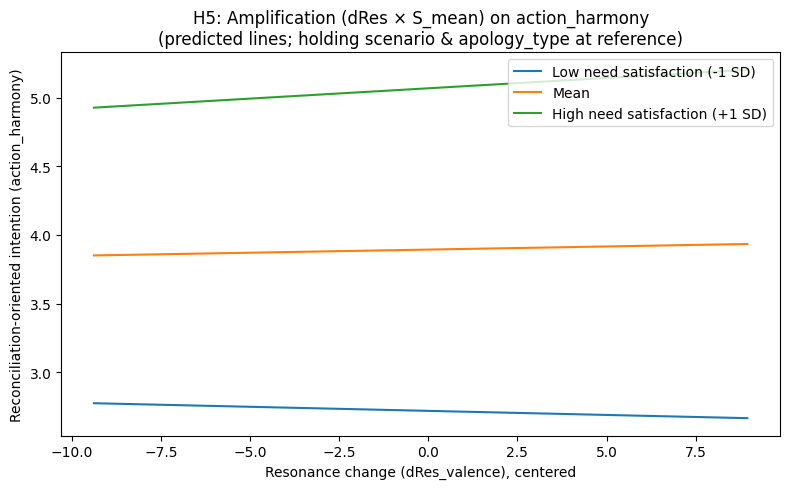


Saved: H5_simple_slopes_action_harmony.png


In [64]:
import matplotlib.pyplot as plt
import pandas as pd
# -----------------------------
# Plot simple slopes for H5 (action_harmony)
#   at low (-1 SD), mean, high (+1 SD) of S_mean
# -----------------------------
S_sd = df["S_mean"].std()
S_levels = [-S_sd, 0, S_sd]  # centered scale
labels = ["Low need satisfaction (-1 SD)", "Mean", "High need satisfaction (+1 SD)"]

x = np.linspace(df["dRes_c"].min(), df["dRes_c"].max(), 60)

plt.figure(figsize=(8,5))
for s_c, lab in zip(S_levels, labels):
    # Ensure 'scenario' is categorical before accessing .cat accessor
    if not pd.api.types.is_categorical_dtype(df["scenario"]):
        df["scenario"] = df["scenario"].astype("category")

    # predicted using the fitted model: include only terms for dRes_c and interaction + intercept;
    # hold scenario at reference and apology_type at reference via formula design automatically is complex.
    # We'll build a prediction dataframe and use model.predict().
    pred_df = pd.DataFrame({
        "dRes_c": x,
        "S_c": s_c,
        "apology_type": "healing",
        "scenario": df["scenario"].cat.categories[0]
    })
    y = mod1.predict(pred_df)
    plt.plot(x, y, label=lab)

plt.xlabel("Resonance change (dRes_valence), centered")
plt.ylabel("Reconciliation-oriented intention (action_harmony)")
plt.title("H5: Amplification (dRes × S_mean) on action_harmony\n(predicted lines; holding scenario & apology_type at reference)")
plt.legend()
plt.tight_layout()
plt.savefig("H5_simple_slopes_action_harmony.png", dpi=200)
plt.show()

print("\nSaved: H5_simple_slopes_action_harmony.png")

/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):
/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):
/tmp/ipython-input-4116046308.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(df["scenario"]):


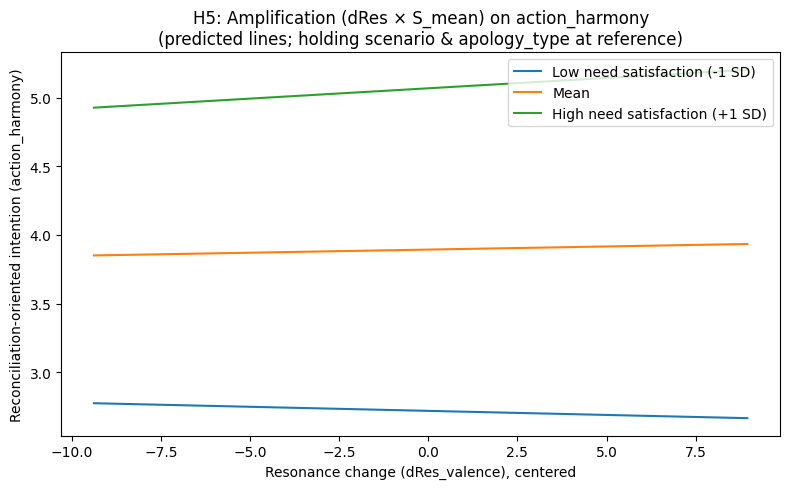


Saved: H5_simple_slopes_action_harmony.png


In [65]:
import matplotlib.pyplot as plt
import pandas as pd
# -----------------------------
# Plot simple slopes for H5 (action_harmony)
#   at low (-1 SD), mean, high (+1 SD) of S_mean
# -----------------------------
S_sd = df["S_mean"].std()
S_levels = [-S_sd, 0, S_sd]  # centered scale
labels = ["Low need satisfaction (-1 SD)", "Mean", "High need satisfaction (+1 SD)"]

x = np.linspace(df["dRes_c"].min(), df["dRes_c"].max(), 60)

plt.figure(figsize=(8,5))
for s_c, lab in zip(S_levels, labels):
    # Ensure 'scenario' is categorical before accessing .cat accessor
    if not pd.api.types.is_categorical_dtype(df["scenario"]):
        df["scenario"] = df["scenario"].astype("category")

    # predicted using the fitted model: include only terms for dRes_c and interaction + intercept;
    # hold scenario at reference and apology_type at reference via formula design automatically is complex.
    # We'll build a prediction dataframe and use model.predict().
    pred_df = pd.DataFrame({
        "dRes_c": x,
        "S_c": s_c,
        "apology_type": "healing",
        "scenario": df["scenario"].cat.categories[0]
    })
    y = mod1.predict(pred_df)
    plt.plot(x, y, label=lab)

plt.xlabel("Resonance change (dRes_valence), centered")
plt.ylabel("Reconciliation-oriented intention (action_harmony)")
plt.title("H5: Amplification (dRes × S_mean) on action_harmony\n(predicted lines; holding scenario & apology_type at reference)")
plt.legend()
plt.tight_layout()
plt.savefig("H5_simple_slopes_action_harmony.png", dpi=200)
plt.show()

print("\nSaved: H5_simple_slopes_action_harmony.png")